In [2]:
# IP addresses from BGP scan
import pandas as pd
import matplotlib.pyplot as plt

# Globally update the font size
plt.rcParams.update({'font.size': 32})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

df = pd.read_csv("data/bgp_scan_results_02_feb_bonaire.csv")
print("Total IP addresses %s" %len(df["target_ip"].unique()))

Total IP addresses 6251958


In [3]:
# Detect possible honeypot IP addresses by finding those with AS 1133 in their BGP open messages.
honeypot_ips = df[df["asn"] == 1133]["target_ip"].unique()

# 2. Filter the original dataframe to exclude any row where the target_ip is in that list
df_cleaned = df[~df["target_ip"].isin(honeypot_ips)]

# 3. Verify the count
print("Final unique IP count: %s" % df_cleaned["target_ip"].nunique())
df_cleaned.to_csv("data/bgp_scan_results_02_feb_bonaire_after_1133.csv")

Final unique IP count: 6250331


In [4]:
# Write honeypot suspected IP addresses to a txt file.
with open("data/honeypots.txt", "w") as f:
    for ip in honeypot_ips:
        f.write(ip + "\n")

print(f"Wrote {len(honeypot_ips)} IPs")

Wrote 1627 IPs


In [7]:
import pandas as pd
df = pd.read_csv("data/bgp_scan_results_02_feb_bonaire_after_1133.csv")
# Category1: TCP timeout (Silent Discard / iACL / GTSM / MD5)
tcp_timeout = df[df["error"] == "tcp_timeout"]
tcp_timeout_count = len(tcp_timeout['target_ip'])
print(f"TCP timeout: {tcp_timeout_count}") # Use single quotes inside f-string

# Category2: Connection refused (RST during handshake / Service Closed)
tcp_refused = df[df["error"] == "tcp_refused"]
tcp_refused_count = len(tcp_refused['target_ip'])
print(f"TCP refused: {tcp_refused_count}")

# Category ignored: Other error OSError (Network unreachable / Routing issues)
os_error = df[df["error"] == "OSError"]
os_error_count = len(os_error['target_ip'])
print(f"OSError: {os_error_count}")


# Category 3: Connection reset
connection_reset = df[(df["bgp_response_type"] == "tcp_reset")]
connection_reset_count = len(connection_reset['target_ip'])
print(f"Connection reset: {connection_reset_count}")

# Category 4: bgp ignore (silent timeout)
bgp_silent_timeout = df[(df["bgp_response_type"] == "bgp_silent_timeout")]
bgp_silent_timeout_count = len(bgp_silent_timeout['target_ip'])
print(f"BGP silent timeout: {bgp_silent_timeout_count}")

# Category 5: bgp immedaitely rejected 
bgp_immediate_rejection = df[df["bgp_response_type"] == "bgp_rejected_immediate"]
bgp_immediate_rejection_count = len(bgp_immediate_rejection['target_ip'])
print(f"BGP immdiate_rejection: {bgp_immediate_rejection_count}")

# Filter only BGP responses
bgp_responded = df[df["outcome"] == "bgp_responded"]

# Group BGP responses per IP
grouped = bgp_responded.groupby("target_ip")["type"].apply(list)

# Initialize mutually exclusive categories
open_then_notification = []
notification_only = []
open_only = []
open_with_keepalive_only = []

for ip, types in grouped.items():
    if "OPEN" in types and "NOTIFICATION" in types:
        open_then_notification.append(ip)
    elif "NOTIFICATION" in types and "OPEN" not in types:
        notification_only.append(ip)
    elif "OPEN" in types and "NOTIFICATION" not in types:
        if "KEEPALIVE" in types:
            open_with_keepalive_only.append(ip)
        else:
            open_only.append(ip)
            


notification_only_count = len(notification_only)
print(f"BGP NOTIFICATION only: {notification_only_count}")

open_only_count = len(open_only)
print(f"BGP OPEN but no NOTIFICATION: {open_only_count}")

open_then_notification_count = len(open_then_notification)
print(f"BGP OPEN followed by NOTIFICATION: {open_then_notification_count}")

open_with_keepalive_only_count = len(open_with_keepalive_only)
print(f"BGP OPEN with KEEPALIVE only: {open_with_keepalive_only_count}")

TCP timeout: 544951
TCP refused: 20564
OSError: 0
Connection reset: 2676126
BGP silent timeout: 765534
BGP immdiate_rejection: 1965734
BGP NOTIFICATION only: 136095
BGP OPEN but no NOTIFICATION: 205
BGP OPEN followed by NOTIFICATION: 141107
BGP OPEN with KEEPALIVE only: 15


In [8]:
len(bgp_responded)

418544

In [9]:
# Save BGP_Responded csvs separately
open_then_notification_df = bgp_responded[bgp_responded["target_ip"].isin(open_then_notification)]
open_then_notification_df.to_csv("results/open_then_notification_02_feb_bonaire.csv")

notification_only_df = bgp_responded[bgp_responded["target_ip"].isin(notification_only)]
notification_only_df.to_csv("results/notification_only_02_feb_bonaire.csv")

open_only_df = bgp_responded[bgp_responded["target_ip"].isin(open_only)]
open_only_df.to_csv("results/open_only_02_feb_bonaire.csv")

open_with_keepalive_only_df = bgp_responded[bgp_responded["target_ip"].isin(open_with_keepalive_only)]
open_with_keepalive_only_df.to_csv("results/open_with_keepalive_02_feb_bonaire.csv")


In [10]:
# Map responses of BGP scan into multiple categories.
# After rescanning bgp-only, remove 14 IPs with honeypots. So, we have total 277,422-14 = 277,408 bgp responding IPs.
# Add 191 IPs to open_then_notification

import pandas as pd
df = pd.read_csv("data/bgp_scan_results_02_feb_bonaire_after_1133.csv")
# Category1: TCP timeout (Silent Discard / iACL / GTSM / MD5)
tcp_timeout = df[df["error"] == "tcp_timeout"]
tcp_timeout_count = len(tcp_timeout['target_ip'])
print(f"TCP timeout: {tcp_timeout_count}") # Use single quotes inside f-string

# Category2: Connection refused (RST during handshake / Service Closed)
tcp_refused = df[df["error"] == "tcp_refused"]
tcp_refused_count = len(tcp_refused['target_ip'])
print(f"TCP refused: {tcp_refused_count}")

# Category ignored: Other error OSError (Network unreachable / Routing issues)
os_error = df[df["error"] == "OSError"]
os_error_count = len(os_error['target_ip'])
print(f"OSError: {os_error_count}")


# Category 3: Connection reset
connection_reset = df[(df["bgp_response_type"] == "tcp_reset")]
connection_reset_count = len(connection_reset['target_ip'])
print(f"Connection reset: {connection_reset_count}")

# Category 4: bgp ignore (silent timeout)
bgp_silent_timeout = df[(df["bgp_response_type"] == "bgp_silent_timeout")]
bgp_silent_timeout_count = len(bgp_silent_timeout['target_ip'])
print(f"BGP silent timeout: {bgp_silent_timeout_count}")

# Category 5: bgp immedaitely rejected 
bgp_immediate_rejection = df[df["bgp_response_type"] == "bgp_rejected_immediate"]
bgp_immediate_rejection_count = len(bgp_immediate_rejection['target_ip'])
print(f"BGP immdiate_rejection: {bgp_immediate_rejection_count}")

# Filter only BGP responses
bgp_responded = df[df["outcome"] == "bgp_responded"]

# Group BGP responses per IP
grouped = bgp_responded.groupby("target_ip")["type"].apply(list)

# Initialize mutually exclusive categories
open_then_notification = []
notification_only = []
open_only = []
open_with_keepalive_only = []

for ip, types in grouped.items():
    if "OPEN" in types and "NOTIFICATION" in types:
        open_then_notification.append(ip)
    elif "NOTIFICATION" in types and "OPEN" not in types:
        notification_only.append(ip)
    elif "OPEN" in types and "NOTIFICATION" not in types:
        if "KEEPALIVE" in types:
            open_with_keepalive_only.append(ip)
        else:
            open_only.append(ip)
            


notification_only_count = len(notification_only)
print(f"BGP NOTIFICATION only: {notification_only_count}")

open_only_count = len(open_only)
open_only_count = 0
print(f"BGP OPEN but no NOTIFICATION: {open_only_count}")

open_then_notification_count = len(open_then_notification)
open_then_notification_count += 191

print(f"BGP OPEN followed by NOTIFICATION: {open_then_notification_count}")

open_with_keepalive_only_count = len(open_with_keepalive_only)
print(f"BGP OPEN with KEEPALIVE only: {open_with_keepalive_only_count}")

TCP timeout: 544951
TCP refused: 20564
OSError: 0
Connection reset: 2676126
BGP silent timeout: 765534
BGP immdiate_rejection: 1965734
BGP NOTIFICATION only: 136095
BGP OPEN but no NOTIFICATION: 0
BGP OPEN followed by NOTIFICATION: 141298
BGP OPEN with KEEPALIVE only: 15


In [11]:
# Save BGP_Responded csvs separately
open_then_notification_df = bgp_responded[bgp_responded["target_ip"].isin(open_then_notification)]
open_then_notification_df.to_csv("results/open_then_notification_02_feb_bonaire.csv")

notification_only_df = bgp_responded[bgp_responded["target_ip"].isin(notification_only)]
notification_only_df.to_csv("results/notification_only_02_feb_bonaire.csv")

open_only_df = bgp_responded[bgp_responded["target_ip"].isin(open_only)]
open_only_df.to_csv("results/open_only_02_feb_bonaire.csv")

open_with_keepalive_only_df = bgp_responded[bgp_responded["target_ip"].isin(open_with_keepalive_only)]
open_with_keepalive_only_df.to_csv("results/open_with_keepalive_02_feb_bonaire.csv")


In [16]:
bgp_responded.groupby("opt_params").size()

opt_params
128, RR                                                                       21714
128, RR, AS4                                                                   7271
AS4                                                                             869
AS4, MP                                                                           1
AS4, MP, MP                                                                       1
MP, 128, RR, 64, AS4, 71                                                          4
MP, 128, RR, AS4, 69, 73, 64                                                      3
MP, 128, RR, ERR, AS4, 6, 69, 73, 64, 71                                          2
MP, AS4, RR, ERR                                                                  1
MP, MP, 128, RR, AS4, 69                                                          8
MP, MP, 128, RR, ERR, AS4, 6, 69, 73, 64                                          3
MP, MP, 128, RR, ERR, AS4, 6, 69, 73, 64, 71                     

In [17]:
# Check the number of open ports for open_only to identify honeypots.
# Code run in Aruba (shodan-honeypots.py)

import shodan
import yaml
import pandas as pd
import time

open_only_df = pd.read_csv("results/open_only_02_feb_bonaire.csv")

API_KEY = "ZFSjortRP8NWfCZAJO3QV6hYJ5JZDWrV"
api = shodan.Shodan(API_KEY)

results = []

for ip in open_only_df["target_ip"].unique():
    try:
        host = api.host(ip)

        results.append({
            "target_ip": ip,
            "no_of_ports": len(host.get("ports", [])),
            "tags_honeypot": "honeypot" in host.get("tags", [])
        })

#         time.sleep(0.5)  # lighter delay is fine for small batches

    except shodan.APIError as e:
        print(f"Error for {ip}: {e}")
        results.append({
            "target_ip": ip,
            "no_of_ports": None,
            "tags_honeypot": None
        })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Merge back into original dataframe
open_only_df = open_only_df.merge(results_df, on="target_ip", how="left")

# Save full dataframe
open_only_df.to_csv("results/open_only_02_feb_bonaire.csv", index=False)


'\nimport shodan\nimport yaml\nimport pandas as pd\nimport time\n\nopen_only_df = pd.read_csv("results/open_only_02_feb_bonaire.csv")\n\nAPI_KEY = "ZFSjortRP8NWfCZAJO3QV6hYJ5JZDWrV"\napi = shodan.Shodan(API_KEY)\n\nresults = []\n\nfor ip in open_only_df["target_ip"].unique():\n    try:\n        host = api.host(ip)\n\n        results.append({\n            "target_ip": ip,\n            "no_of_ports": len(host.get("ports", [])),\n            "tags_honeypot": "honeypot" in host.get("tags", [])\n        })\n\n#         time.sleep(0.5)  # lighter delay is fine for small batches\n\n    except shodan.APIError as e:\n        print(f"Error for {ip}: {e}")\n        results.append({\n            "target_ip": ip,\n            "no_of_ports": None,\n            "tags_honeypot": None\n        })\n\n# Convert results to DataFrame\nresults_df = pd.DataFrame(results)\n\n# Merge back into original dataframe\nopen_only_df = open_only_df.merge(results_df, on="target_ip", how="left")\n\n# Save full dataframe

In [113]:
# Count number of routers and public ASNs for open with keepalive
import pandas as pd
open_with_keepalive = pd.read_csv("results/open_with_keepalive_02_feb_bonaire_router_mapping.csv") 

# ---- Functions to classify ASNs ----
def is_private_asn(asn):
    """Check if ASN is private."""
    if isinstance(asn, str):
        asn = asn.replace("AS", "").strip()
    try:
        asn = int(asn)
    except ValueError:
        return False
    return (64512 <= asn <= 65534) or (4200000000 <= asn <= 4294967294)

def is_bogon_asn(asn):
    """Check if ASN is reserved or documentation ASN (bogon)."""
    if isinstance(asn, str):
        asn = asn.replace("AS", "").strip()
    try:
        asn = int(asn)
    except ValueError:
        return False
    return (
        asn == 0 or
        asn == 65535 or
        asn == 4294967295 or
        64496 <= asn <= 64511 or
        65536 <= asn <= 65551  # include documentation/test ASNs

    )

# Look only for rows with public ASNs in effective_asn
open_with_keepalive['effective_asn'] = open_with_keepalive['effective_asn'].astype(int)
open_with_keepalive_public_asn_only = open_with_keepalive[
    open_with_keepalive["effective_asn"].notna() &
    (~open_with_keepalive["effective_asn"].apply(is_private_asn)) &
    (~open_with_keepalive["effective_asn"].apply(is_bogon_asn)) &
    (open_with_keepalive["effective_asn"] != 23456)
]

# open_with_keepalive_result = open_with_keepalive_public_asn_only.groupby('effective_asn').agg(
#     num_ips_of_asn=('effective_asn','size'),
#     unique_router_count=('router_key','nunique'),
#     router_keys=('router_key', lambda x: list(set(x)))  # collect all router_keys, and unique only
# ).reset_index()

# # Sort by unique_router_count in descending order
# open_with_keepalive_result = open_with_keepalive_result.sort_values(by='unique_router_count', ascending=False)

# total_no_routers = open_with_keepalive_result["unique_router_count"].sum()
# no_public_asns = open_with_keepalive_result["effective_asn"].count()

total_no_routers = open_with_keepalive_public_asn_only["router_key"].nunique()
no_public_asns = open_with_keepalive_public_asn_only["effective_asn"].nunique()

print(f"Open_with_keepalive_result: Number of public ASNs is {no_public_asns}, total number of routers is {total_no_routers}.\n")
# print(f"The result is \n {open_with_keepalive_result}")


Open_with_keepalive_result: Number of public ASNs is 8, total number of routers is 8.



In [19]:
# Find ASN of BGP responding IP addresses (Open with/without notifications). 
# Take ASN from open message. If there is no ASN, map router ID to ASN using IPinfo data. 
# For Open only, go to line #73 df = df[df["tags_honeypot"] == False] # Consider only non honeypot IP address.

import pandas as pd
import ipaddress
import numpy as np

# Paths
bgp_file = "results/open_then_notification_02_feb_bonaire.csv"
asn_file = "data/2026-02-02_country_asn.csv"
output_file = "results/open_then_notification_02_feb_bonaire_router_mapping.csv"

# -----------------------------
# ASN Classification Functions
# -----------------------------

def is_private_asn(asn):
    try:
        asn = int(asn)
    except:
        return False
    return (
        64512 <= asn <= 65534 or
        4200000000 <= asn <= 4294967294
    )

def is_bogon_asn(asn):
    try:
        asn = int(asn)
    except:
        return False
    return (
        asn == 0 or
        asn == 65535 or
        asn == 4294967295 or
        64496 <= asn <= 64511 or
        65536 <= asn <= 65551   # documentation range (includes 65540)
    )

def is_public_asn(asn):
    if pd.isna(asn):
        return False
    try:
        asn = int(asn)
    except:
        return False

    return not (
        is_private_asn(asn) or
        is_bogon_asn(asn) or
        asn == 23456   # AS_TRANS
    )

def is_public_ipv4(ip):
    try:
        ip_obj = ipaddress.IPv4Address(ip)
        return not (
            ip_obj.is_private or
            ip_obj.is_reserved or
            ip_obj.is_loopback or
            ip_obj.is_multicast
        )
    except:
        return False

# --- Step 1: Load BGP file ---
# orig_df = pd.read_csv(bgp_file, usecols=["target_ip", "bgp_id", "asn", "tags_honeypot"])
orig_df = pd.read_csv(bgp_file)

print(f"Original df {len(orig_df)}")

# df = orig_df[orig_df["tags_honeypot"] != True] # Consider only non honeypot IP address
df = orig_df
print(f"No. of unique IP addresses {df['target_ip'].nunique()}")

# Keep only non-empty bgp_id and ASN
# Empty ASN and BGP ID (Notification message)
empty_asn_df = df[(df["bgp_id"].isna()) | (df["bgp_id"].isna())]
print(f"{len(empty_asn_df)} IP addresses has no ASN and bgp_id." )

df = df[df["bgp_id"].notna() & (df["bgp_id"] != "")].copy()
df["bgp_id"] = df["bgp_id"].astype(str)

# Convert ASN to numeric safely
df["asn"] = pd.to_numeric(df["asn"], errors="coerce")

# --- Step 2: Identify non-public ASN rows ---
def is_public_asn(asn):
    if pd.isna(asn):
        return False
    asn = int(asn)
    return not (
        64512 <= asn <= 65534 or      # private 2-byte
        4200000000 <= asn <= 4294967294 or  # private 4-byte
        asn == 23456                  # AS_TRANS
    )

df["is_non_public_asn"] = ~df["asn"].apply(is_public_asn)

# --- Step 3: Load IPinfo ASN bulk file ---
df_asn = pd.read_csv(asn_file)

# Keep IPv4 only
df_asn = df_asn[df_asn["start_ip"].str.contains(r"^\d+\.\d+\.\d+\.\d+$")].copy()

# Convert IP ranges to integers for fast search
df_asn["start_int"] = df_asn["start_ip"].apply(lambda x: int(ipaddress.IPv4Address(x)))
df_asn["end_int"] = df_asn["end_ip"].apply(lambda x: int(ipaddress.IPv4Address(x)))

# Sort by start_int
df_asn = df_asn.sort_values("start_int").reset_index(drop=True)
starts = df_asn["start_int"].values
ends = df_asn["end_int"].values
asns = df_asn["asn"].values

# Function to map bgp_id to ASN
def map_asn(ip_str):
    try:
        ip_int = int(ipaddress.IPv4Address(ip_str))
        idx = np.searchsorted(starts, ip_int, side="right") - 1
        if idx >= 0 and ip_int <= ends[idx]:
            return str(asns[idx])  # numeric ASN as string
    except:
        pass
    return ""

# --- Step 4: Map bgp_id to ASN for ALL rows with public bgp_id ---
df["asn_from_bgp_id"] = ""

mask_public_bgp_id = df["bgp_id"].apply(is_public_ipv4)
df.loc[mask_public_bgp_id, "asn_from_bgp_id"] = \
    df.loc[mask_public_bgp_id, "bgp_id"].apply(map_asn)

# Clean ASN string (remove AS prefix if any)
df["asn_from_bgp_id"] = (
    df["asn_from_bgp_id"]
    .astype(str)
    .str.replace(r"AS", "", regex=True)
)

# Convert mapped ASN to numeric safely
df["asn_from_bgp_id"] = pd.to_numeric(df["asn_from_bgp_id"], errors="coerce")


# --- Step 5: Compute effective_asn ---
# Default: ASN from OPEN
df["effective_asn"] = df["asn"]

# Replace if:
# 1. ASN from OPEN is non-public
# 2. asn_from_bgp_id exists
# 3. asn_from_bgp_id is public

mask_replace = (
    df["is_non_public_asn"] &                 # ASN from OPEN is non-public
    df["asn_from_bgp_id"].notna() &           # mapping exists
    (~df["asn_from_bgp_id"].apply(is_private_asn)) &
    (~df["asn_from_bgp_id"].apply(is_bogon_asn)) &
    (df["asn_from_bgp_id"] != 23456)
)

df.loc[mask_replace, "effective_asn"] = df.loc[mask_replace, "asn_from_bgp_id"]



# --- Step 6: Build router_key ---
df["router_key"] = df.apply(
    lambda row: f"{row['bgp_id']}_{int(row['effective_asn'])}"
    if pd.notna(row["effective_asn"])
    else f"{row['bgp_id']}_ASnan",
    axis=1
)


# Save final CSV
df.to_csv(output_file, index=False)
print(f"Saved final router mapping to {output_file}")

Original df 282214
No. of unique IP addresses 141107
141107 IP addresses has no ASN and bgp_id.
Saved final router mapping to results/open_then_notification_02_feb_bonaire_router_mapping.csv


In [98]:
# Count the number of IP addresses with public, private, bogon, AS 23456, and no ASN. 
import pandas as pd

df = pd.read_csv("results/open_then_notification_02_feb_bonaire_router_mapping.csv")

# ---- Functions to classify ASNs ----
def is_private_asn(asn):
    """Check if ASN is private."""
    if isinstance(asn, str):
        asn = asn.replace("AS", "").strip()
    try:
        asn = int(asn)
    except ValueError:
        return False
    return (64512 <= asn <= 65534) or (4200000000 <= asn <= 4294967294)

def is_bogon_asn(asn):
    """Check if ASN is reserved or documentation ASN (bogon)."""
    if isinstance(asn, str):
        asn = asn.replace("AS", "").strip()
    try:
        asn = int(asn)
    except ValueError:
        return False
    return (
        asn == 0 or
        asn == 65535 or
        asn == 4294967295 or
        64496 <= asn <= 64511 or
        65536 <= asn <= 65551  # include documentation/test ASNs

    )


# ---- Categories ----
# Now classify based on effective_asn
no_asn = df[df["effective_asn"].isna() | (df["effective_asn"] == "")]
asn_23456 = df[df["effective_asn"] == 23456]

private_asn_only = df[
    df["effective_asn"].notna() &
    df["effective_asn"].apply(is_private_asn)
]

bogon_asn_only = df[
    df["effective_asn"].notna() &
    df["effective_asn"].apply(is_bogon_asn)
]

public_asn_only = df[
    df["effective_asn"].notna() &
    (~df["effective_asn"].apply(is_private_asn)) &
    (~df["effective_asn"].apply(is_bogon_asn)) &
    (df["effective_asn"] != 23456)
]
print(f"IP addresses with public ASNs: {len(public_asn_only)}")
print(f"IP addresses with private ASNs (excluding AS23456): {len(private_asn_only)}")
print(f"IP addresses with bogon/reserved ASNs: {len(bogon_asn_only)}")
print(f"IP addresses with AS23456: {len(asn_23456)}")
print(f"IP addresses with no ASNs: {len(no_asn)}")

# print("\n---- Unique counts: AS23456 ----")
# print(f"# of BGP IDs: {asn_23456['bgp_id'].nunique()}")
# print(f"# of Router keys: {asn_23456['router_key'].nunique()}")

IP addresses with public ASNs: 119221
IP addresses with private ASNs (excluding AS23456): 13587
IP addresses with bogon/reserved ASNs: 228
IP addresses with AS23456: 8071
IP addresses with no ASNs: 0


In [103]:
# Find ASN of BGP responding IP addresses (Notification only). 

import pandas as pd
import ipaddress
import numpy as np

# Paths
bgp_file = "results/notification_only_02_feb_bonaire.csv"
asn_file = "data/2026-02-02_country_asn.csv"
output_file = "results/notification_only_02_feb_bonaire_router_mapping.csv"

# --- Step 1: Load BGP file ---
df = pd.read_csv(bgp_file, usecols=["target_ip", "bgp_id", "asn"])


# --- Step 2: Load IPinfo ASN bulk file ---
df_asn = pd.read_csv(asn_file)

# Keep IPv4 only
df_asn = df_asn[df_asn["start_ip"].str.contains(r"^\d+\.\d+\.\d+\.\d+$")].copy()

# Convert IP ranges to integers for fast search
df_asn["start_int"] = df_asn["start_ip"].apply(lambda x: int(ipaddress.IPv4Address(x)))
df_asn["end_int"] = df_asn["end_ip"].apply(lambda x: int(ipaddress.IPv4Address(x)))

# Sort by start_int
df_asn = df_asn.sort_values("start_int").reset_index(drop=True)
starts = df_asn["start_int"].values
ends = df_asn["end_int"].values
asns = df_asn["asn"].values

# Function to map bgp_id to ASN
def map_asn(ip_str):
    try:
        ip_int = int(ipaddress.IPv4Address(ip_str))
        idx = np.searchsorted(starts, ip_int, side="right") - 1
        if idx >= 0 and ip_int <= ends[idx]:
            return str(asns[idx])  # numeric ASN as string
    except:
        pass
    return ""

# Create effective_asn directly
df["effective_asn"] = ""

df["effective_asn"] = df["target_ip"].apply(map_asn)

# Replace AS string from effective_asn
df["effective_asn"] = (
    df["effective_asn"]
    .astype(str)
    .str.replace("AS", "", regex=False)
    .str.strip()
)

# Save effective_asn as integet
df["effective_asn"] = pd.to_numeric(df["effective_asn"], errors="coerce")

# Save final CSV
df.to_csv(output_file, index=False)
print(f"Saved final router mapping to {output_file}")

Saved final router mapping to results/notification_only_02_feb_bonaire_router_mapping.csv


In [104]:
# Count number of routers and public ASNs for open then notification
import pandas as pd
open_then_notification = pd.read_csv("results/open_then_notification_02_feb_bonaire_router_mapping.csv") 

# ---- Functions to classify ASNs ----
def is_private_asn(asn):
    """Check if ASN is private."""
    if isinstance(asn, str):
        asn = asn.replace("AS", "").strip()
    try:
        asn = int(asn)
    except ValueError:
        return False
    return (64512 <= asn <= 65534) or (4200000000 <= asn <= 4294967294)

def is_bogon_asn(asn):
    """Check if ASN is reserved or documentation ASN (bogon)."""
    if isinstance(asn, str):
        asn = asn.replace("AS", "").strip()
    try:
        asn = int(asn)
    except ValueError:
        return False
    return (
        asn == 0 or
        asn == 65535 or
        asn == 4294967295 or
        64496 <= asn <= 64511 or
        65536 <= asn <= 65551  # include documentation/test ASNs

    )



# Look only for rows with public ASNs in effective_asn
open_then_notification['effective_asn'] = open_then_notification['effective_asn'].astype(int)
open_then_notification_public_asn_only = open_then_notification[
    open_then_notification["effective_asn"].notna() &
    (~open_then_notification["effective_asn"].apply(is_private_asn)) &
    (~open_then_notification["effective_asn"].apply(is_bogon_asn)) &
    (open_then_notification["effective_asn"] != 23456)
]

# open_then_notification_result = open_then_notification_public_asn_only.groupby('effective_asn').agg(
#     num_ips_of_asn=('effective_asn','size'),
#     unique_router_count=('router_key','nunique'),
#     router_keys=('router_key', lambda x: list(set(x)))  # collect all router_keys, and unique only
# ).reset_index()

# # Sort by unique_router_count in descending order
# open_then_notification_result = open_then_notification_result.sort_values(by='unique_router_count', ascending=False)

# total_no_routers = open_then_notification_result["unique_router_count"].sum()
# no_public_asns = open_then_notification_result["effective_asn"].count()
total_no_routers = open_then_notification_public_asn_only["router_key"].nunique()
no_public_asns = open_then_notification_public_asn_only["effective_asn"].nunique()


print(f"open_then_notification: Number of public ASNs is {no_public_asns}, total number of routers is {total_no_routers}.\n")
# print(f"The result is \n {open_with_keepalive_result}")


open_then_notification: Number of public ASNs is 3352, total number of routers is 16171.



In [105]:
# Count number of routers and public ASNs for open only
import pandas as pd
open_only = pd.read_csv("results/open_only_02_feb_bonaire_router_mapping.csv") 

# ---- Functions to classify ASNs ----
def is_private_asn(asn):
    """Check if ASN is private."""
    if isinstance(asn, str):
        asn = asn.replace("AS", "").strip()
    try:
        asn = int(asn)
    except ValueError:
        return False
    return (64512 <= asn <= 65534) or (4200000000 <= asn <= 4294967294)

def is_bogon_asn(asn):
    """Check if ASN is reserved or documentation ASN (bogon)."""
    if isinstance(asn, str):
        asn = asn.replace("AS", "").strip()
    try:
        asn = int(asn)
    except ValueError:
        return False
    return (
        asn == 0 or
        asn == 65535 or
        asn == 4294967295 or
        64496 <= asn <= 64511 or
        65536 <= asn <= 65551  # include documentation/test ASNs

    )




# Look only for rows with public ASNs in effective_asn
open_only['effective_asn'] = open_only['effective_asn'].astype(int)
open_only_public_asn_only = open_only[
    open_only["effective_asn"].notna() &
    (~open_only["effective_asn"].apply(is_private_asn)) &
    (~open_only["effective_asn"].apply(is_bogon_asn)) &
    (open_only["effective_asn"] != 23456)
]

# open_only_result = open_only_public_asn_only.groupby('effective_asn').agg(
#     num_ips_of_asn=('effective_asn','size'),
#     unique_router_count=('router_key','nunique'),
#     router_keys=('router_key', lambda x: list(set(x)))  # collect all router_keys, and unique only
# ).reset_index()

# # Sort by unique_router_count in descending order
# open_only_result = open_only_result.sort_values(by='unique_router_count', ascending=False)

# total_no_routers = open_only_result["unique_router_count"].sum()
# no_public_asns = open_only_result["effective_asn"].count()

total_no_routers = open_only_public_asn_only["router_key"].nunique()
no_public_asns = open_only_public_asn_only["effective_asn"].nunique()

print(f"open_only: Number of public ASNs is {no_public_asns}, total number of routers is {total_no_routers}.\n")
# print(f"The result is \n {open_with_keepalive_result}")


open_only: Number of public ASNs is 88, total number of routers is 104.



In [122]:
# Distribution of number of routers across ASes based on router_key.
import pandas as pd
df = pd.read_csv("results/open_keepalive_notification_only_02_feb_bonaire_router_mapping.csv")

# Convert effective asn to int
df['effective_asn'] = df['effective_asn'].astype(int)


# ---- Functions to classify ASNs ----
def is_private_asn(asn):
    """Check if ASN is private."""
    if isinstance(asn, str):
        asn = asn.replace("AS", "").strip()
    try:
        asn = int(asn)
    except ValueError:
        return False
    return (64512 <= asn <= 65534) or (4200000000 <= asn <= 4294967294)

def is_bogon_asn(asn):
    """Check if ASN is reserved or documentation ASN (bogon)."""
    if isinstance(asn, str):
        asn = asn.replace("AS", "").strip()
    try:
        asn = int(asn)
    except ValueError:
        return False
    return (
        asn == 0 or
        asn == 65535 or
        asn == 4294967295 or
        64496 <= asn <= 64511 or
        65536 <= asn <= 65551  # include documentation/test ASNs

    )



# Look only for rows with public ASNs in effective_asn
df['effective_asn'] = df['effective_asn'].astype(int)
public_asn_only = df[
    df["effective_asn"].notna() &
    (~df["effective_asn"].apply(is_private_asn)) &
    (~df["effective_asn"].apply(is_bogon_asn)) &
    (df["effective_asn"] != 23456)
]


result = public_asn_only.groupby('effective_asn').agg(
    num_ips_of_asn=('effective_asn','size'),
    unique_router_count=('router_key','nunique')
).reset_index()

# Sort by unique_router_count in descending order
result = result.sort_values(by='unique_router_count', ascending=False)

total_no_routers = result["unique_router_count"].sum()
no_public_asns = result["effective_asn"].count()
print(f"Number of public ASNs is {no_public_asns}, total number of routers is {total_no_routers}.\n")
print(f"The result is \n {result}")

Number of public ASNs is 3424, total number of routers is 16274.

The result is 
       effective_asn  num_ips_of_asn  unique_router_count
150            3352            4197                 3538
253            6461             494                  493
333            8151             920                  312
855           21859            1772                  294
629           15525             412                  217
...             ...             ...                  ...
2057          57608               2                    1
2056          57575               3                    1
2055          57531               3                    1
698           17444               7                    1
3423     4153132211               1                    1

[3424 rows x 3 columns]


/tmp/ipykernel_20379/4125966892.py:3: DtypeWarning: Columns (3,4,5,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("results/open_keepalive_notification_only_02_feb_bonaire_router_mapping.csv")


In [123]:
as3352_routers = public_asn_only[public_asn_only["effective_asn"] == 198949][["target_ip", "router_key"]]

# Extract router_id (part before "_")
as3352_routers["router_id"] = as3352_routers["router_key"].str.split("_").str[0]

# Select desired columns
as3352_routers_out = as3352_routers[["router_id", "target_ip"]]

# Sort by router_id (and optionally by target_ip for cleaner output)
as3352_routers_out = as3352_routers_out.sort_values(by=["router_id"])

# Export to CSV
# as3352_routers_out.to_csv("results/as3352_routers.csv", index=False)

print(as3352_routers_out)

             router_id       target_ip
2112    141.226.108.35  141.226.108.35
93468   141.226.108.43  141.226.108.43
135834   167.17.128.35   167.17.128.35
8569     167.17.128.43   167.17.128.43
58490    167.17.153.35   167.17.153.35
82330    167.17.153.43   167.17.153.43
41407     167.86.33.35    167.86.33.35
70747     167.86.33.43    167.86.33.43
25197     167.86.49.35    167.86.49.35
100374    167.86.49.43    167.86.49.43
125235  176.100.181.35  176.100.181.35
138307  176.100.181.43  176.100.181.43
75853   185.139.240.35  185.139.240.35
88704   185.139.240.43  185.139.240.43
99291    185.144.88.35   185.144.88.35
109936   185.144.88.43   185.144.88.43
52185     66.22.102.35    66.22.102.35
92433     66.22.102.43    66.22.102.43
117338    66.22.112.35    66.22.112.35
2024      66.22.112.43    66.22.112.43
79387     66.22.117.35    66.22.117.35
55150     66.22.117.43    66.22.117.43
69033     66.22.122.35    66.22.122.35
115643    66.22.122.43    66.22.122.43
89108     66.22.123.35   

In [124]:
# Count the number of IP adddress per routers
ips_per_router = (
    public_asn_only
        .groupby("router_key")["target_ip"]
        .count()
        .reset_index()
        .rename(columns={
            "router_key": "router_map",
            "target_ip": "no_of_ips"
        })
)
ips_per_router.sort_values("no_of_ips", ascending=False)
sorted_counts = ips_per_router['no_of_ips'].sort_values()
cdf = sorted_counts.rank(method='first') / len(sorted_counts)
plt.rcParams.update({
    'font.size': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.figure(figsize=(10,6))
plt.plot(sorted_counts, cdf, marker='.', linestyle='none')
plt.xscale('log')
plt.xlabel('Number of IP addresses per router (log scale)')
plt.ylabel('Fraction of routers')
# plt.title('CDF of Routers per ASN')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.savefig("images/cdf_routers_ips.pdf")
plt.show()

NameError: name 'plt' is not defined

In [112]:
ips_per_router[(ips_per_router["no_of_ips"] >= 2 ) & (ips_per_router["no_of_ips"] <= 2)]

,router_map,no_of_ips
2,0.0.0.0_27717,2
13,1.0.0.112_13335,2
16,1.1.1.1_133168,2
18,1.1.1.1_20016,2
21,1.1.1.1_37436,2
...,...,...
16221,95.164.20.1_205905,2
16224,95.214.68.8_209681,2
16225,95.214.68.9_209681,2
16240,97.71.158.130_33363,2


In [16]:
public_asn_only[public_asn_only["router_key"].str.contains("3352")].iloc[10:20]

,Unnamed: 0.1,Unnamed: 0,target_ip,tcp_connected,bgp_responded,tcp_reset,tcp_latency,bgp_latency,bgp_response_type,outcome,...,opt_params_raw,opt_params,error_code,error_subcode,date,is_non_public_asn,asn_from_bgp_id,effective_asn,router_key,tags_honeypot
265,11724.0,11728.0,194.224.195.233,True,True,False,0.042,0.043,bgp_open_received,bgp_responded,...,NaN,NaN,NaN,NaN,2026-02-06T15:54:11.691508,True,3352.0,3352,81.41.200.14_3352,NaN
270,11951.0,11955.0,194.224.238.225,True,True,False,0.086,0.092,bgp_open_received,bgp_responded,...,NaN,NaN,NaN,NaN,2026-02-06T15:54:12.448074,True,3352.0,3352,217.124.84.85_3352,NaN
312,13619.0,13623.0,195.76.26.225,True,True,False,0.064,0.064,bgp_open_received,bgp_responded,...,NaN,NaN,NaN,NaN,2026-02-06T15:55:22.349985,True,3352.0,3352,217.124.90.136_3352,NaN
341,15065.0,15070.0,195.57.49.57,True,True,False,0.078,0.084,bgp_open_received,bgp_responded,...,NaN,NaN,NaN,NaN,2026-02-06T15:55:52.602959,True,3352.0,3352,82.198.100.178_3352,NaN
360,16225.0,16230.0,195.77.44.29,True,True,False,0.046,0.046,bgp_open_received,bgp_responded,...,NaN,NaN,NaN,NaN,2026-02-06T15:56:53.680131,True,3352.0,3352,80.58.190.215_3352,NaN
493,22629.0,22634.0,195.76.191.153,True,True,False,0.078,0.080,bgp_open_received,bgp_responded,...,NaN,NaN,NaN,NaN,2026-02-06T16:00:12.593837,True,3352.0,3352,217.11.98.253_3352,NaN
528,24747.0,24752.0,194.179.117.81,True,True,False,0.046,0.046,bgp_open_received,bgp_responded,...,NaN,NaN,NaN,NaN,2026-02-06T16:02:02.041876,True,3352.0,3352,80.58.191.101_3352,NaN
565,26375.0,26382.0,195.76.77.153,True,True,False,0.095,0.090,bgp_open_received,bgp_responded,...,NaN,NaN,NaN,NaN,2026-02-06T16:02:03.905261,True,3352.0,3352,217.11.96.224_3352,NaN
584,27473.0,27480.0,213.4.117.169,True,True,False,0.064,0.070,bgp_open_received,bgp_responded,...,NaN,NaN,NaN,NaN,2026-02-06T16:03:45.563212,True,3352.0,3352,217.124.78.4_3352,NaN
591,27884.0,27891.0,194.224.122.97,True,True,False,0.095,0.080,bgp_open_received,bgp_responded,...,NaN,NaN,NaN,NaN,2026-02-06T16:03:45.551252,True,3352.0,3352,217.124.96.225_3352,NaN


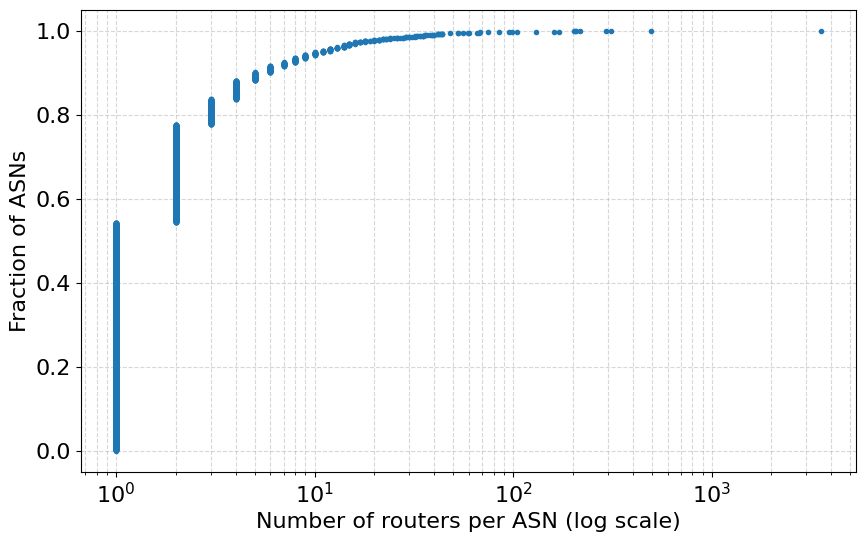

In [125]:
import matplotlib.pyplot as plt

# ---------- IEEE-style global settings ----------
plt.rcParams.update({
    'font.size': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

sorted_counts = result['unique_router_count'].sort_values()
cdf = sorted_counts.rank(method='first') / len(sorted_counts)

plt.figure(figsize=(10,6))
plt.plot(sorted_counts, cdf, marker='.', linestyle='none')
plt.xscale('log')
plt.xlabel('Number of routers per ASN (log scale)')
plt.ylabel('Fraction of ASNs')
# plt.title('CDF of Routers per ASN')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.savefig("images/cdf_asn_routers.pdf")
plt.show()



In [126]:
# Sort by router count
result.sort_values("num_ips_of_asn", ascending=False)
# df_sorted = result.sort_values('unique_router_count')

# # Calculate cumulative percentage of IPs
# df_sorted['cum_ip_pct'] = df_sorted['num_ips_of_asn'].cumsum() / df_sorted['num_ips_of_asn'].sum()

# # Your original CDF (Percentile of ASNs)
# df_sorted['asn_percentile'] = range(1, len(df_sorted) + 1) / len(df_sorted)
# df_sorted

,effective_asn,num_ips_of_asn,unique_router_count
150,3352,4197,3538
682,17054,2084,171
855,21859,1772,294
3011,209242,1673,2
573,13767,1570,67
...,...,...,...
980,24289,1,1
1713,47394,1,1
1707,47169,1,1
934,23661,1,1


In [15]:
import requests
import time
import pandas as pd

results = []

for _, row in top_asns.iterrows():
    asn = row["effective_asn"]
    no_of_routers = row["unique_router_count"]

    url = f"https://api.asrank.caida.org/v2/restful/asns/{asn}?populate=1"
    r = requests.get(url)

    if r.status_code == 200:
        json_data = r.json()
        data = json_data.get("data", {})
        org = data.get("asn") or {}
        org_name = org.get("asnName", "Unknown")
    else:
        org_name = f"HTTP_error_{r.status_code}"

    results.append((asn, no_of_routers, org_name))

    time.sleep(0.2)

df_out = pd.DataFrame(results, columns=["ASN", "# of routers", "Organization"])
df_out.to_csv("results/top_asns_more_than_25_routers.csv", index=False)

print(df_out)

      ASN  # of routers          Organization
0    3352          3538  Telefonica_de_Espana
1    6461           493             ZAYO-6461
2    8151           312                      
3   21859           294               ZEN-ECN
4   15525           217          MEO-EMPRESAS
..    ...           ...                   ...
58  23991            28           RANKS-AS-BD
59  53818            27                MDUPRO
60  21267            26       Wavenet-AS21267
61   8865            26        ASN-BIAMAN-EDU
62  32653            26             ENETWORKS

[63 rows x 3 columns]


In [6]:
top_asns

,effective_asn,num_ips_of_asn,unique_router_count
150,3352,4197,3538
253,6461,494,493
333,8151,920,312
855,21859,1772,294
629,15525,412,217
1215,30844,394,208
1550,42689,436,206
823,20473,421,203
682,17054,2084,171
784,19009,1489,161


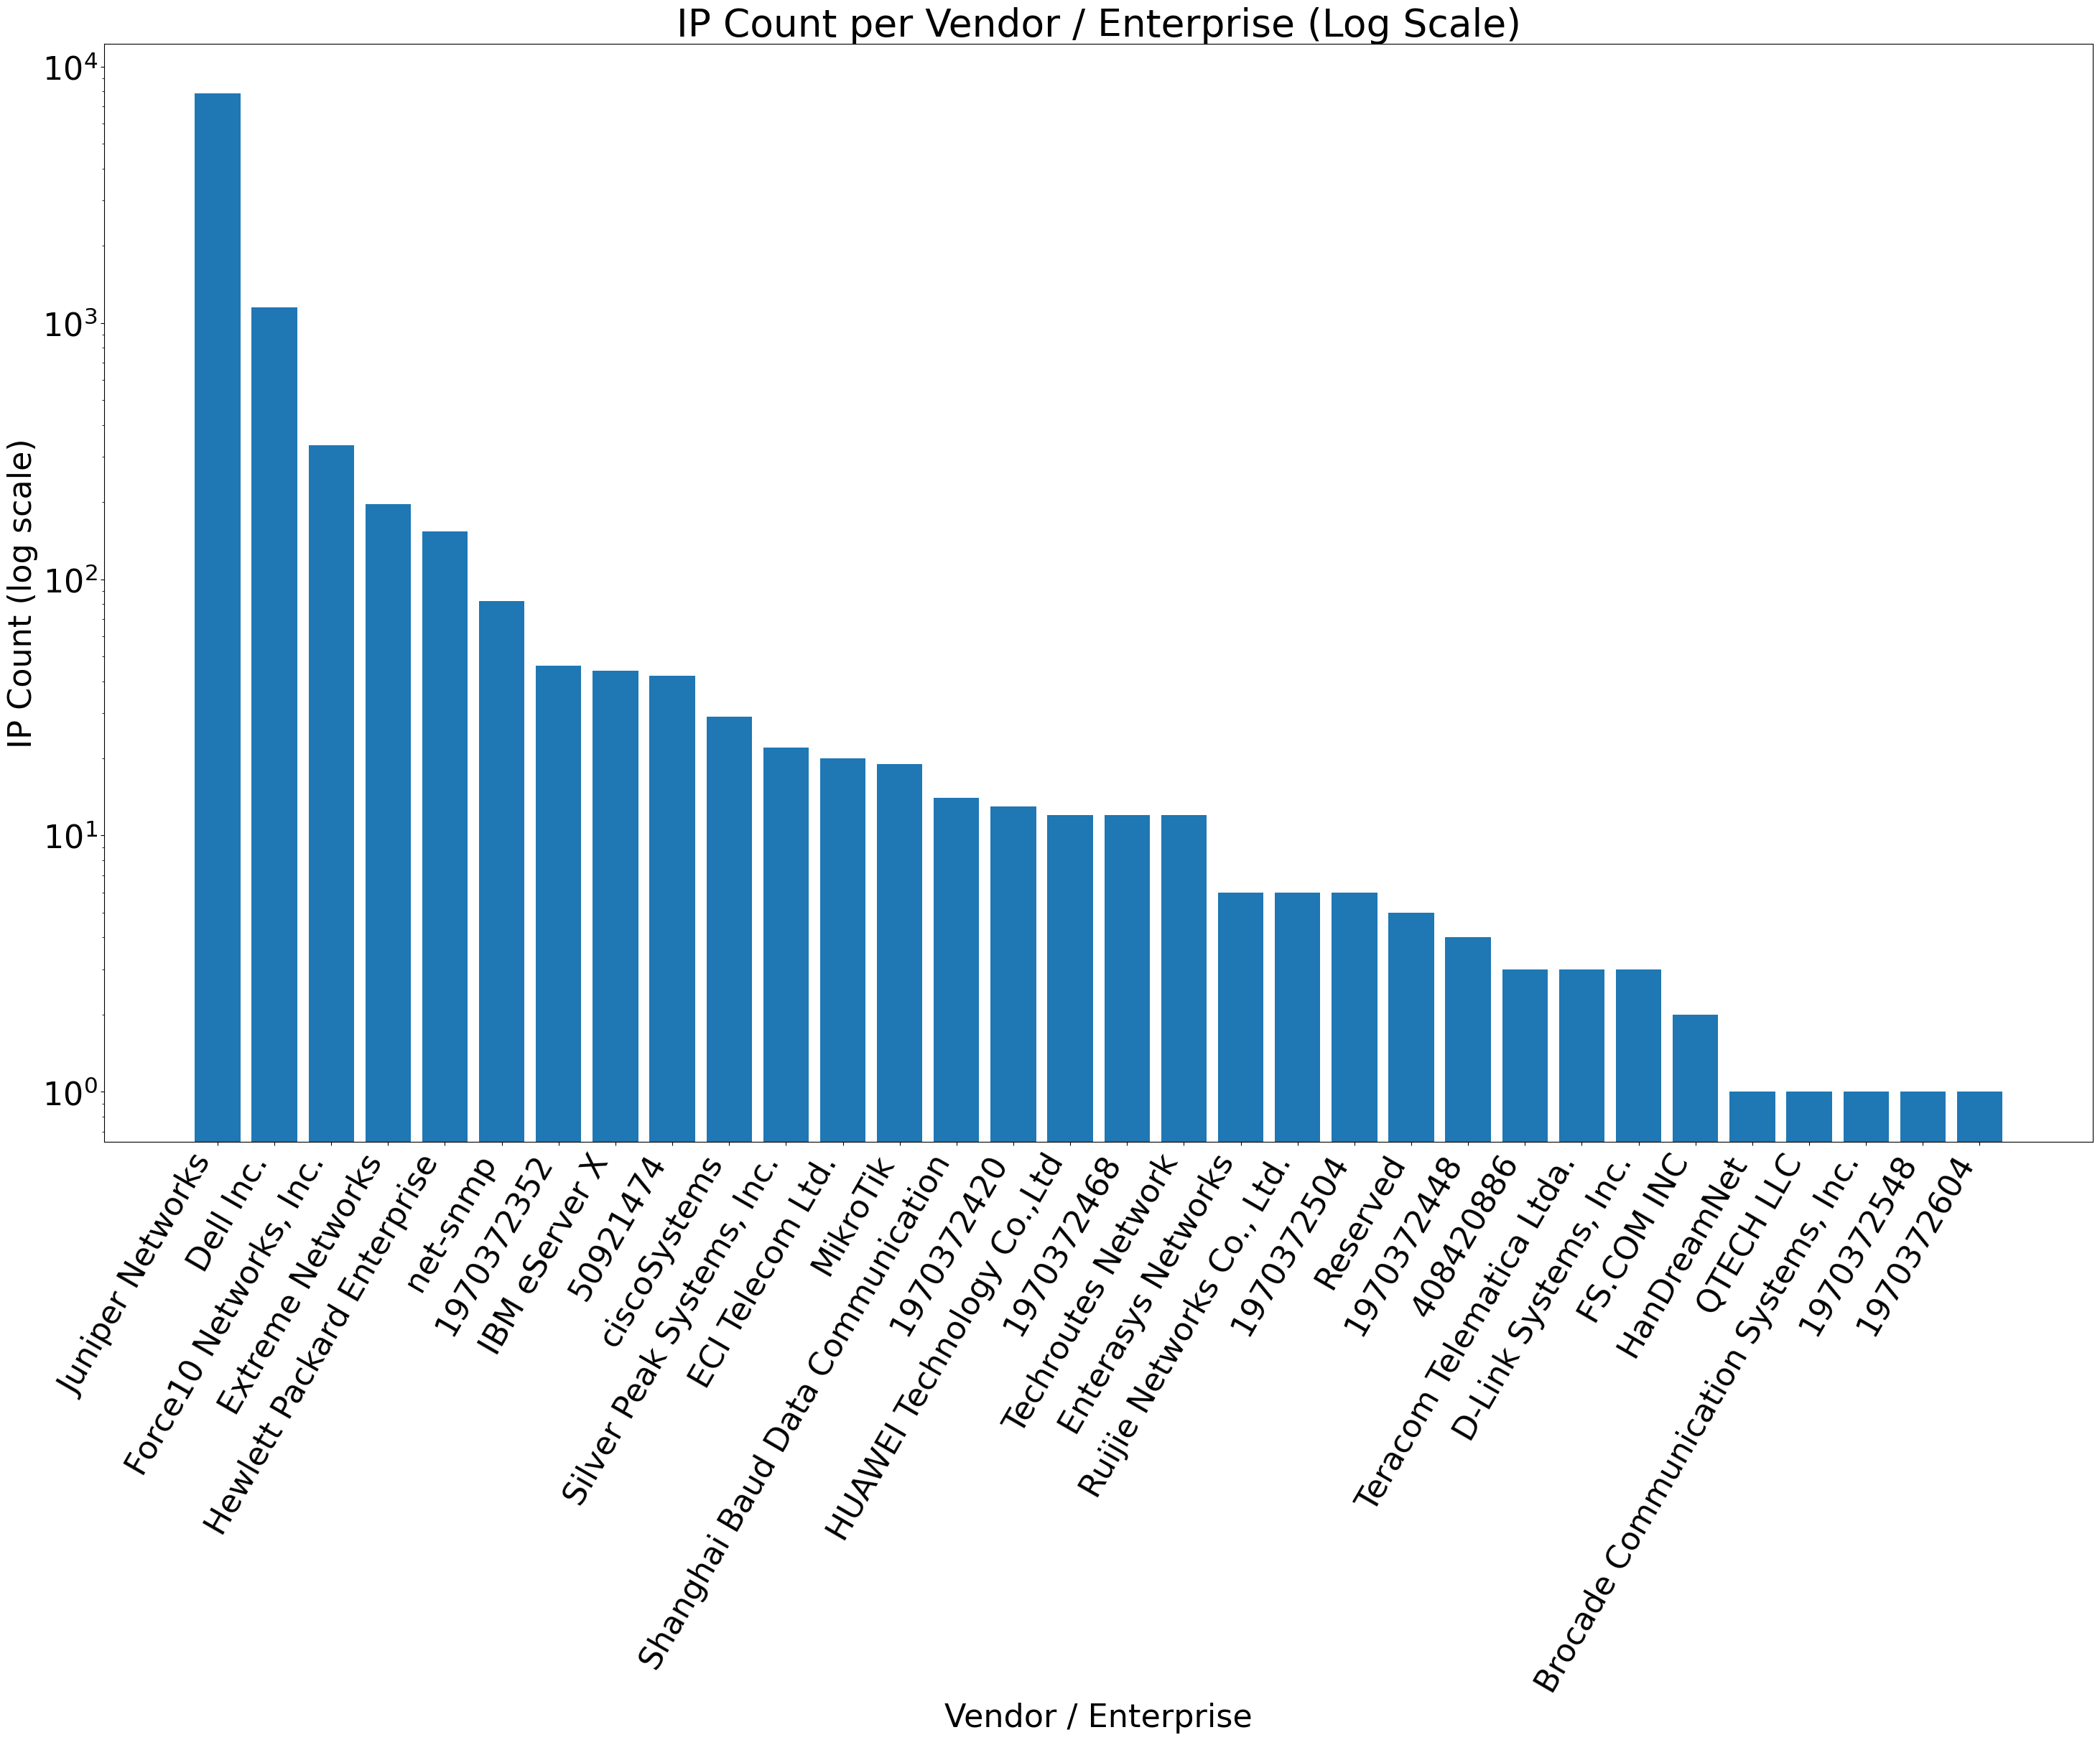

In [15]:
# Cat 1 and cat 2 responders with vendor information
import pandas as pd
import matplotlib.pyplot as plt

# Globally update the font size
plt.rcParams.update({'font.size': 32})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
df = pd.read_csv("data/cat1_snmp_shodan_details.csv")
# df2= pd.read_csv("data/cat2_snmp_shodan_details.csv")


# Use Vendor if available, otherwise Enterprise
df["x_label"] = df["Vendor"].fillna(df["enterprise"].astype(str))

# Plot
plt.figure(figsize=(30, 25))
plt.bar(df["x_label"], df["ip_count"])
plt.yscale("log")
plt.xticks(rotation=60, ha="right")
plt.xlabel("Vendor / Enterprise")
plt.ylabel("IP Count (log scale)")
plt.title("IP Count per Vendor / Enterprise (Log Scale)")
plt.tight_layout()
plt.savefig("images/cat1_vendor_count.pdf")
plt.show()


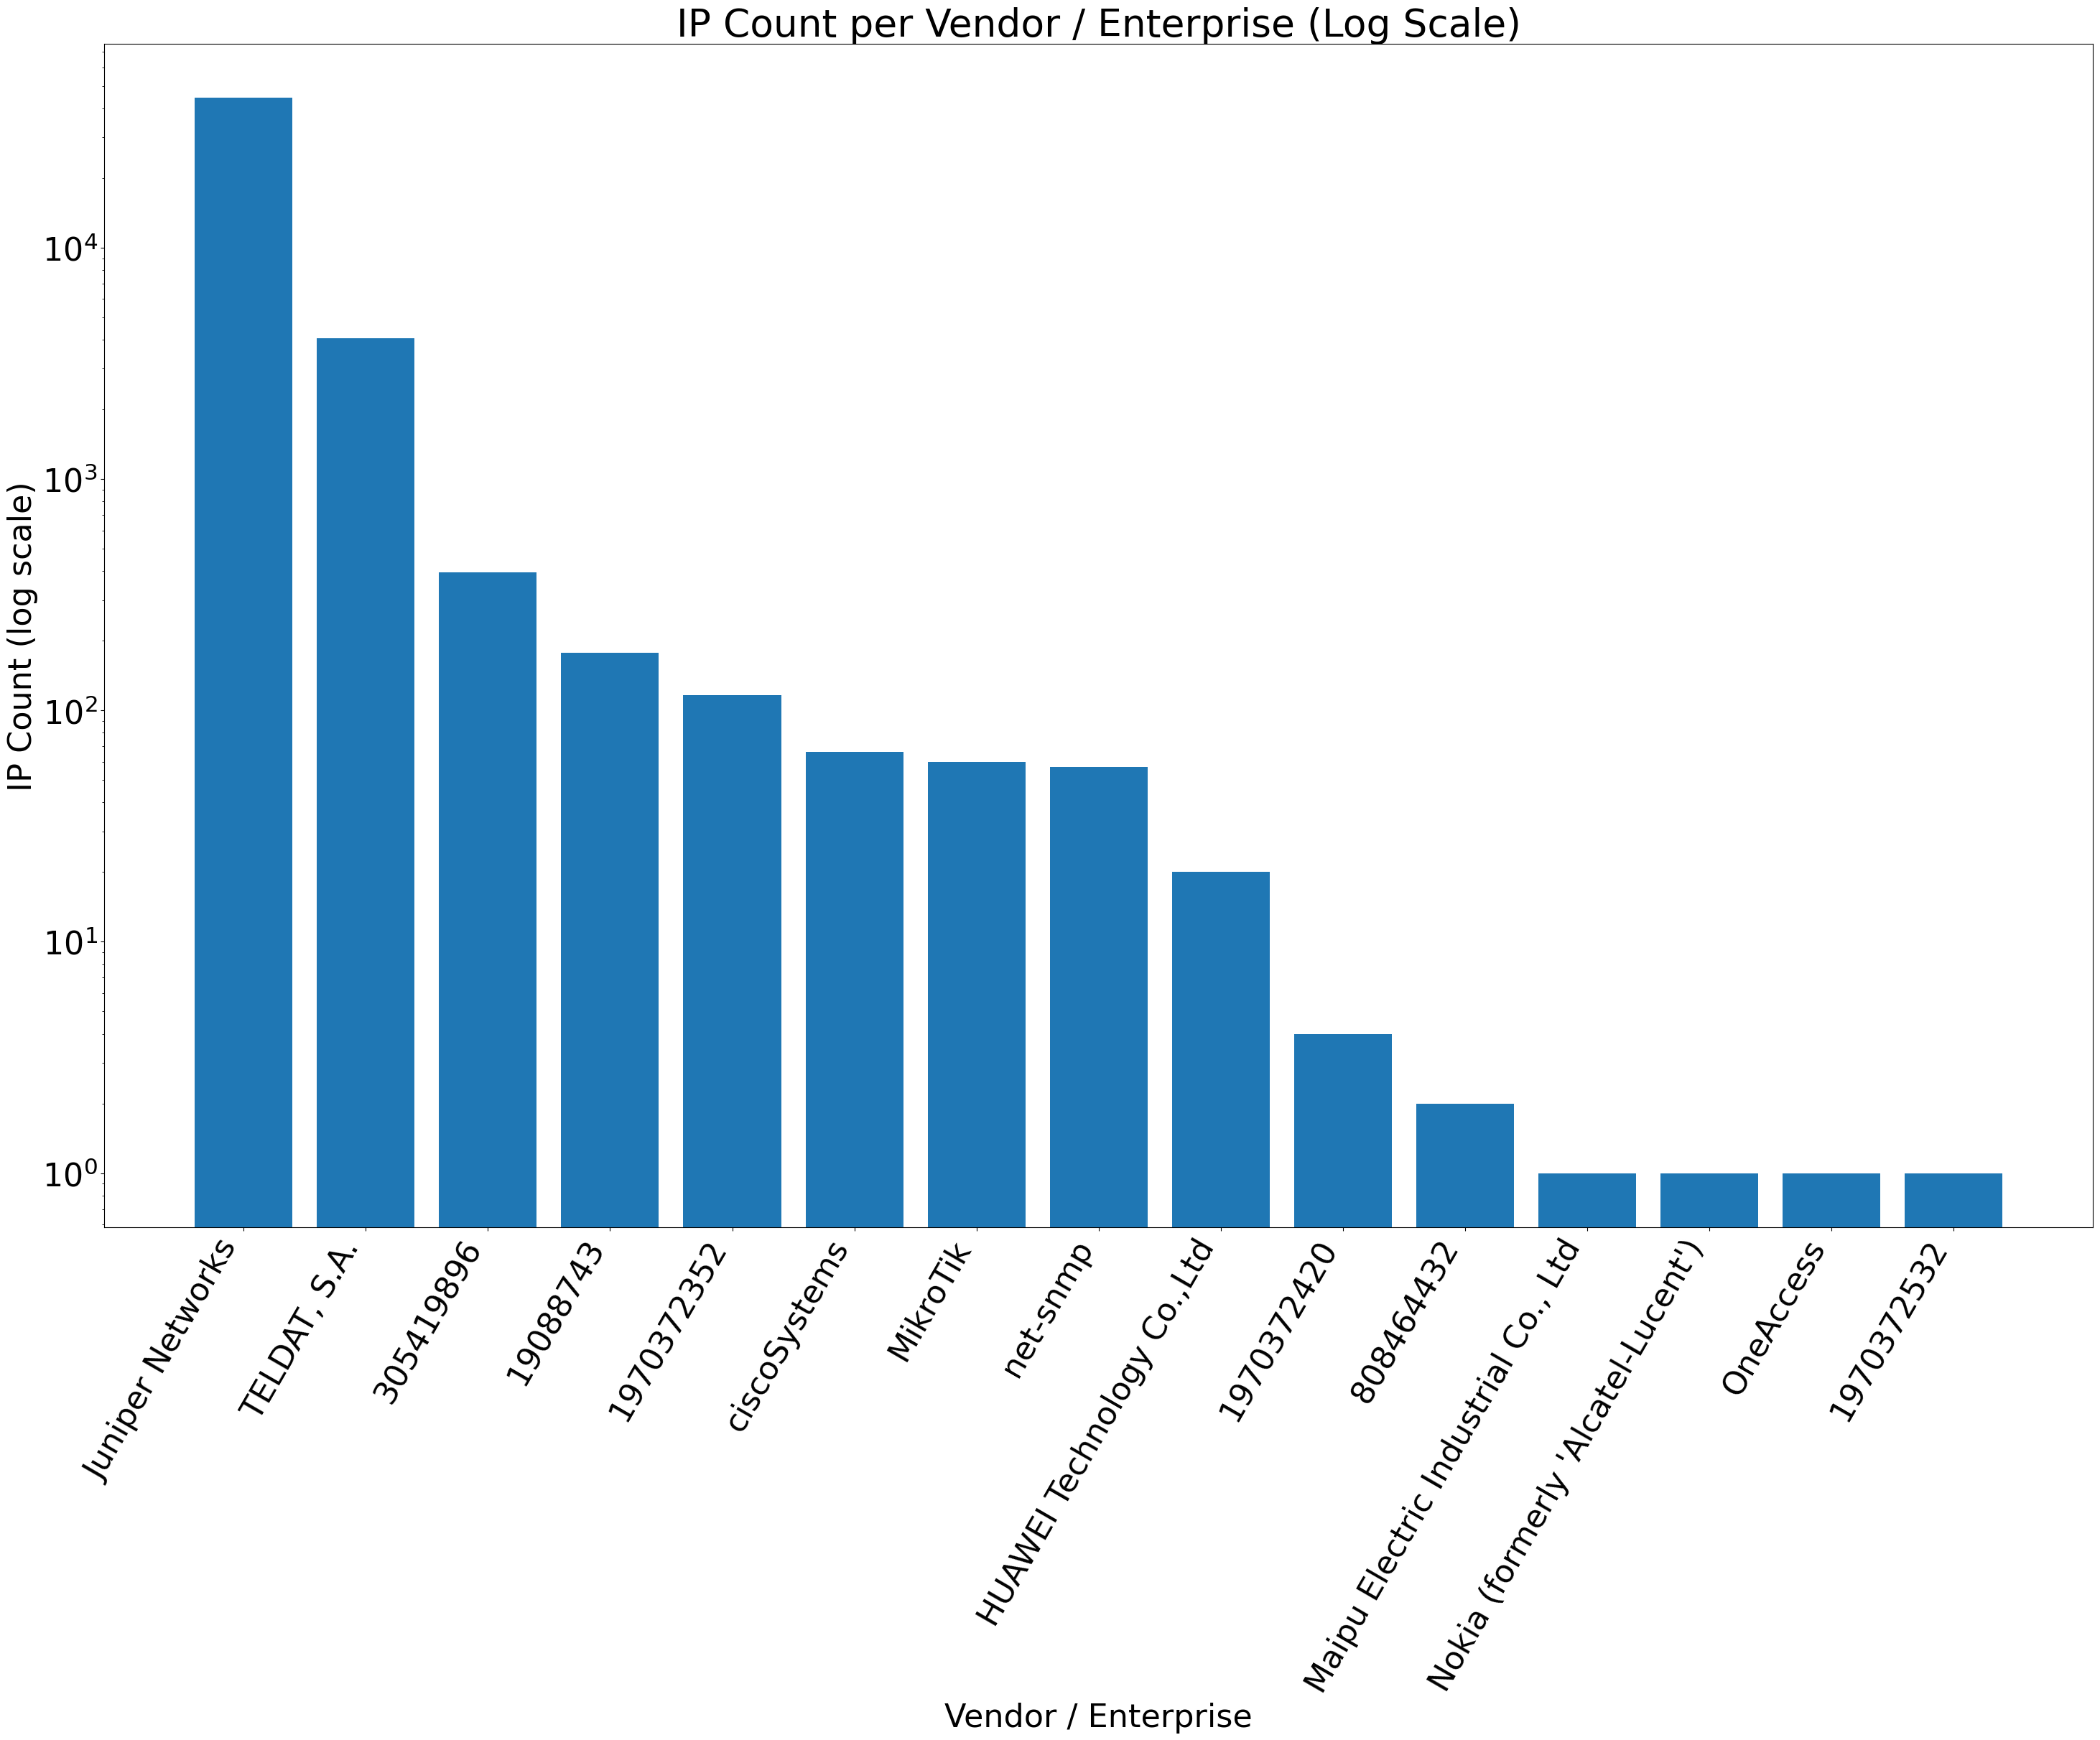

In [16]:
# Cat 1 and cat 2 responders with vendor information
import pandas as pd
import matplotlib.pyplot as plt

# Globally update the font size
plt.rcParams.update({'font.size': 32})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
df = pd.read_csv("data/cat2_snmp_shodan_details.csv")
# df2= pd.read_csv("data/cat2_snmp_shodan_details.csv")


# Use Vendor if available, otherwise Enterprise
df["x_label"] = df["Vendor"].fillna(df["enterprise"].astype(str))

# Plot
plt.figure(figsize=(30, 25))
plt.bar(df["x_label"], df["ip_count"])
plt.yscale("log")
plt.xticks(rotation=60, ha="right")
plt.xlabel("Vendor / Enterprise")
plt.ylabel("IP Count (log scale)")
plt.title("IP Count per Vendor / Enterprise (Log Scale)")
plt.tight_layout()
plt.savefig("images/cat2_vendor_count.pdf")
plt.show()

In [2]:
# Country wise details. Country found using monocle whois -C NL
import pandas as pd

df1 = pd.read_csv("data/bgp_router_mapping.csv") 
df2 = pd.read_csv("/home/shyam/Desktop/asns_in.csv")
# Step 1: Normalize both columns to integers
df1["asn_num"] = df1["asn"].str.replace("AS", "", regex=False).astype(int)
df2["asn_num"] = df2["asn"].astype(int)

# Step 2: Find overlapping ASNs
overlap = set(df1["asn_num"]) & set(df2["asn_num"])
print("Overlapping ASNs:", list(overlap))

Overlapping ASNs: [141312, 136716, 133648, 55824, 17426, 132115, 132116, 58898, 134674, 55836, 150050, 135724, 133680, 135734, 150589, 45117, 39486, 150596, 138311, 17483, 133720, 135257, 9829, 132717, 149616, 136306, 55410, 136308, 135799, 132215, 24186, 134277, 151691, 4755, 4758, 132768, 153259, 55470, 133296, 151732, 134325, 134330, 136894, 134338, 45769, 9430, 151773, 134886, 134375, 141549, 137972, 139515, 45820, 141566, 134911, 17665, 134913, 203020, 134927, 55577, 9498, 149275, 18207, 18209, 59178, 23860, 18229, 58678, 23872, 140110, 133975, 17754, 45916, 55644, 133982, 140641, 17762, 9583, 132976, 135031, 133001, 133007, 133011, 140187, 132524, 133037, 137132, 137645, 139195, 137662, 56268, 132559, 7633, 138202, 45536, 56290, 24560, 150008, 58875, 17917]
